In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示异常

In [8]:
df=pd.read_csv('data/new_messy_clinic_appointments.csv',parse_dates=['appointment_date','booking_date'])
#读入数据，顺便让日期列直接识别为日期类型

In [9]:
print("数据规模：",df.shape)

数据规模： (1000, 10)


In [14]:
print("\n前5行数据：")
print(df.head(5))


前5行数据：
   patient_id       patient_name  age   gender appointment_date booking_date  \
0        1080     Tammy Williams   76   Female       2026-02-26   2024-12-03   
1        1074   Megan Strickland   69  Unknown       2025-05-23   2024-06-12   
2        1067   Amanda Schroeder   79  Unknown       2025-11-30   2024-08-05   
3        1072  Anthony Mcpherson   47  Unknown       2025-05-18   2024-09-09   
4        1092     Benjamin Brown   45  Unknown       2026-03-07   2024-08-17   

               doctor   department  billing_amount follow_up_required  
0  Christopher Graham   Cardiology          425.80                Yes  
1       Brandon Lewis  Orthopedics          344.26                Yes  
2      Deanna Edwards    Neurology          203.34                Yes  
3       Karen Parsons      General           85.76                 No  
4    Andrea Hernandez      General           84.44                Yes  


In [12]:
# 查看各列数据类型，确认日期已变为 datetime64
print("\n数据列信息：")
print(df.info())


数据列信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          1000 non-null   int64         
 1   patient_name        1000 non-null   object        
 2   age                 1000 non-null   int64         
 3   gender              1000 non-null   object        
 4   appointment_date    1000 non-null   datetime64[ns]
 5   booking_date        1000 non-null   datetime64[ns]
 6   doctor              1000 non-null   object        
 7   department          1000 non-null   object        
 8   billing_amount      1000 non-null   float64       
 9   follow_up_required  1000 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 78.2+ KB
None


In [13]:
# 查看年龄和账单金额的描述统计（均值、中位数、最大最小值等）
print("\n数值列统计描述：")
print(df[['age', 'billing_amount']].describe())


数值列统计描述：
               age  billing_amount
count  1000.000000     1000.000000
mean     53.750000      275.803030
std      21.137604      126.833397
min      18.000000       51.380000
25%      34.000000      166.495000
50%      55.000000      269.840000
75%      71.000000      383.872500
max      90.000000      499.750000


In [15]:
df['waiting_days'] = (df['appointment_date'] - df['booking_date']).dt.days
#计算患者等待天数

In [17]:
print(df.head())

   patient_id       patient_name  age   gender appointment_date booking_date  \
0        1080     Tammy Williams   76   Female       2026-02-26   2024-12-03   
1        1074   Megan Strickland   69  Unknown       2025-05-23   2024-06-12   
2        1067   Amanda Schroeder   79  Unknown       2025-11-30   2024-08-05   
3        1072  Anthony Mcpherson   47  Unknown       2025-05-18   2024-09-09   
4        1092     Benjamin Brown   45  Unknown       2026-03-07   2024-08-17   

               doctor   department  billing_amount follow_up_required  \
0  Christopher Graham   Cardiology          425.80                Yes   
1       Brandon Lewis  Orthopedics          344.26                Yes   
2      Deanna Edwards    Neurology          203.34                Yes   
3       Karen Parsons      General           85.76                 No   
4    Andrea Hernandez      General           84.44                Yes   

   waiting_days  
0           450  
1           345  
2           482  
3       

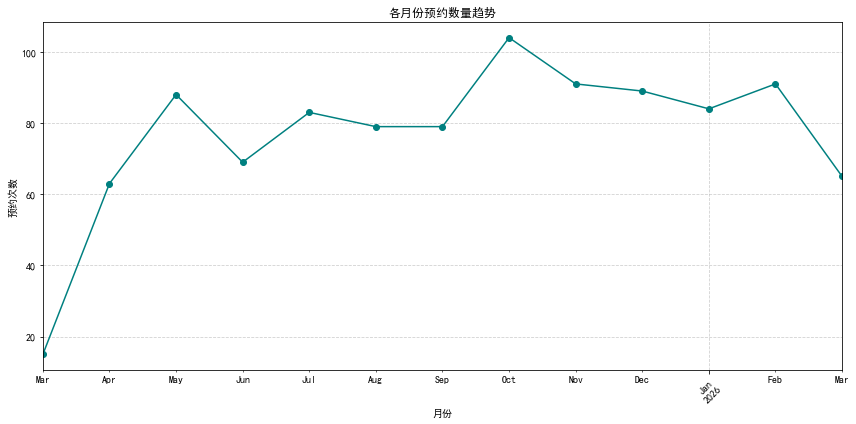

In [18]:
# 提取月份（2025-03, 2025-04 ...）
df['month'] = df['appointment_date'].dt.to_period('M')

# 按月份分组计数
monthly_counts = df.groupby('month').size()

# 绘制折线图
plt.figure(figsize=(12, 6))               # 设置画布大小
monthly_counts.plot(marker='o', color='teal')
plt.title('各月份预约数量趋势')           # 标题
plt.xlabel('月份')                        # x轴标签
plt.ylabel('预约次数')                    # y轴标签
plt.grid(True, linestyle='--', alpha=0.6) # 加网格线，方便看数值
plt.xticks(rotation=45)                   # 旋转 x 轴标签，防止重叠
plt.tight_layout()                        # 自动调整布局
plt.show()                                # 显示图表

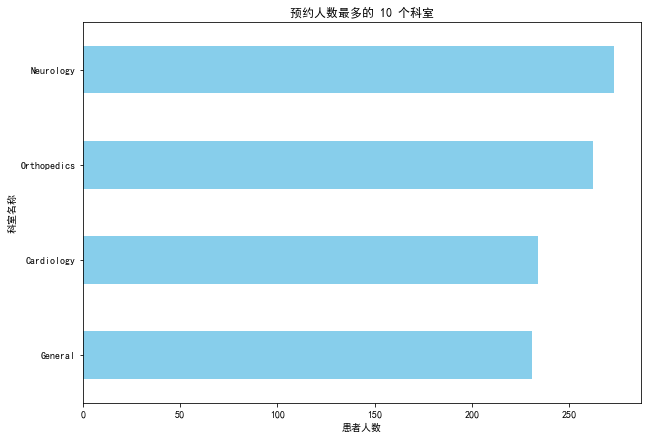

In [19]:
# 统计各科室人数
dept_counts = df['department'].value_counts()

# 取前10个科室（如果太多只显示前10）
top_depts = dept_counts.head(10)

plt.figure(figsize=(10, 7))
top_depts.sort_values().plot(kind='barh', color='skyblue')
plt.title('预约人数最多的 10 个科室')
plt.xlabel('患者人数')
plt.ylabel('科室名称')
plt.show()

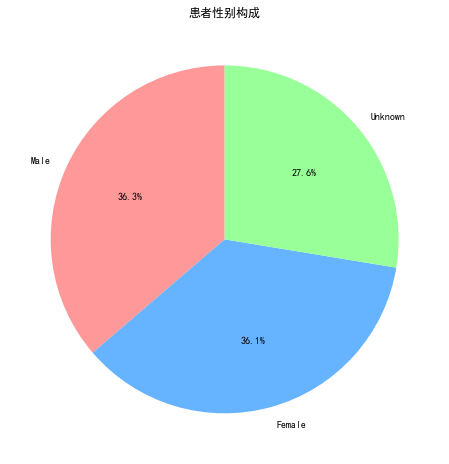

In [20]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('患者性别构成')
plt.show()

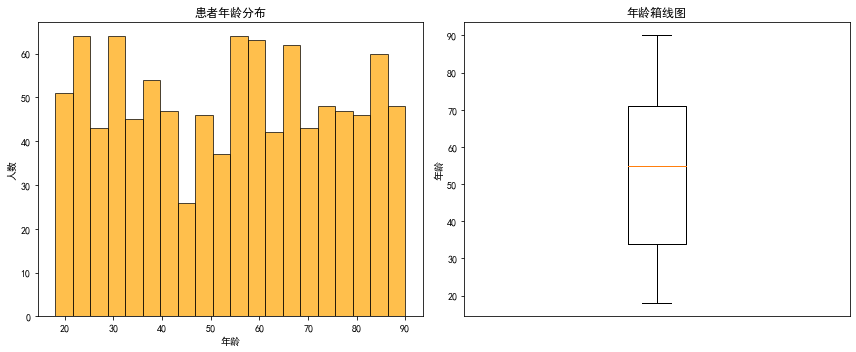

In [21]:
# 直方图：看年龄整体分布形态
plt.figure(figsize=(12, 5))

# 子图1：直方图
plt.subplot(1, 2, 1)
plt.hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.title('患者年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')

# 子图2：箱线图（看是否有异常年龄）
plt.subplot(1, 2, 2)
plt.boxplot(df['age'].dropna())
plt.title('年龄箱线图')
plt.ylabel('年龄')
plt.xticks([])  # 去掉 x 轴标记，只留 y 轴

plt.tight_layout()
plt.show()

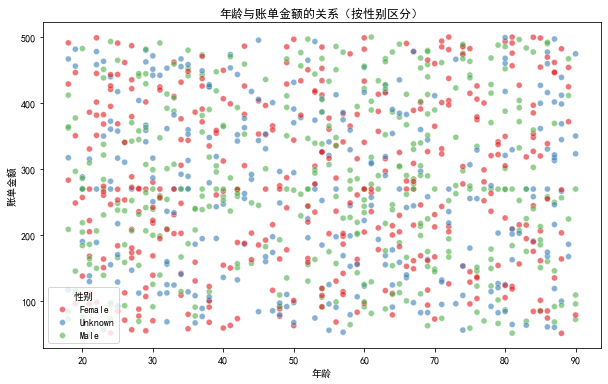

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='billing_amount', hue='gender', data=df, alpha=0.6, palette='Set1')
plt.title('年龄与账单金额的关系（按性别区分）')
plt.xlabel('年龄')
plt.ylabel('账单金额')
plt.legend(title='性别')
plt.show()

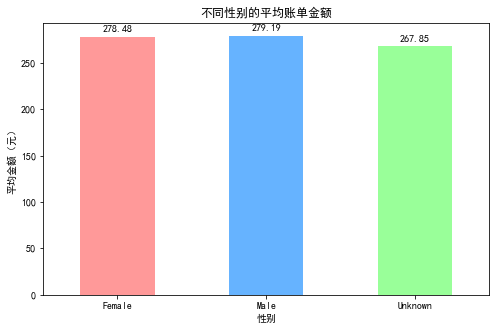

In [23]:
avg_bill_gender = df.groupby('gender')['billing_amount'].mean().round(2)

plt.figure(figsize=(8, 5))
avg_bill_gender.plot(kind='bar', color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('不同性别的平均账单金额')
plt.xlabel('性别')
plt.ylabel('平均金额（元）')
plt.xticks(rotation=0)
for i, v in enumerate(avg_bill_gender):
    plt.text(i, v+5, str(v), ha='center')  # 在柱子上标注具体数值
plt.show()

In [24]:
# ==========================================
# 1. 等待天数的整体分布
# ==========================================
print("等待天数统计描述：")
print(df['waiting_days'].describe())

等待天数统计描述：
count    1000.000000
mean      274.563000
std       170.492327
min         2.000000
25%       130.750000
50%       258.500000
75%       395.250000
max       728.000000
Name: waiting_days, dtype: float64


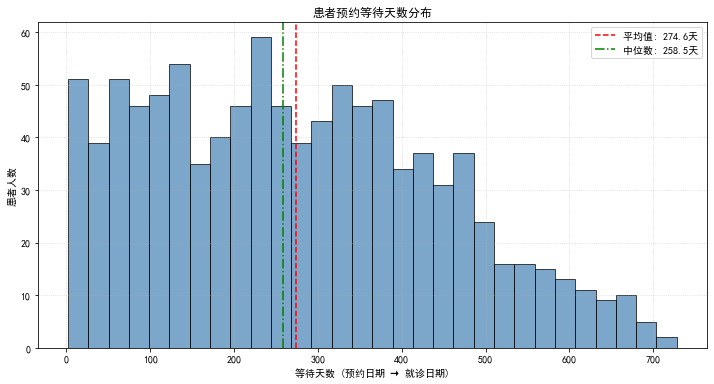

In [25]:
# 画直方图，观察等待天数的集中趋势和异常值
plt.figure(figsize=(12, 6))
plt.hist(df['waiting_days'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['waiting_days'].mean(), color='red', linestyle='--', label=f'平均值: {df["waiting_days"].mean():.1f}天')
plt.axvline(df['waiting_days'].median(), color='green', linestyle='-.', label=f'中位数: {df["waiting_days"].median():.1f}天')
plt.title('患者预约等待天数分布')
plt.xlabel('等待天数 (预约日期 → 就诊日期)')
plt.ylabel('患者人数')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()


各科室平均等待天数（降序）：
              平均等待   中位等待  患者数
department                    
General      280.3  258.0  231
Orthopedics  277.2  267.5  262
Neurology    271.4  261.0  273
Cardiology   269.7  255.0  234


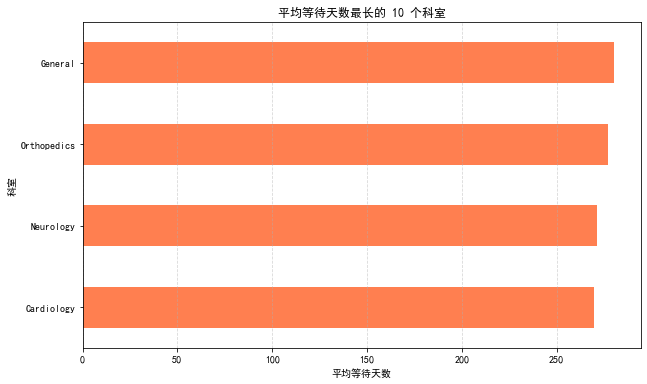

In [27]:
# 2. 按科室分析平均等待天数（找出等待最长的科室）

dept_wait = df.groupby('department')['waiting_days'].agg(['mean', 'median', 'count']).round(1)
dept_wait.columns = ['平均等待', '中位等待', '患者数']
# 按平均等待降序排序
dept_wait_sorted = dept_wait.sort_values('平均等待', ascending=False)
print("\n各科室平均等待天数（降序）：")
print(dept_wait_sorted)

# 可视化（取前10个科室）
top10_dept_wait = dept_wait_sorted.head(10)
plt.figure(figsize=(10, 6))
top10_dept_wait['平均等待'].sort_values().plot(kind='barh', color='coral')
plt.title('平均等待天数最长的 10 个科室')
plt.xlabel('平均等待天数')
plt.ylabel('科室')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()